# SQR 3-Gate Optimization Notebook (State-Target Focus)

This notebook only does the following:
1. Loads the decomposition file and extracts the 3 SQR gates.
2. Optimizes only cavity levels **0, 1, 2**.
3. Uses **fixed Gaussian sigma fraction = 1/6**.
4. Optimizes for **target-state transfer** over multiple initial states (phase-sensitive superpositions).
5. Runs two passes:
   - Pass A: duration bound `550 ns` to `1900 ns` (reference).
   - Pass B: duration bound `600 ns` to `2000 ns` (requested rerun).
6. Reports mean/min target-state fidelity and correction SQR parameters for each gate.

In [7]:
import json
from pathlib import Path
from dataclasses import replace

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.optimize import dual_annealing, minimize

import examples.sqr_multitone_study as sms
from cqed_sim.core.ideal_gates import sqr_op

In [8]:
# Model + target gates + fixed optimization support (levels 0/1/2)
chi_hz = -2.84e6
duration_ref_s = 1e-6
coherent_alpha = 0.8 + 0.2j

system = sms.SystemParams(
    n_max=6,
    chi_nominal_hz=chi_hz,
    chi_easy_hz=chi_hz,
    chi_hard_hz=chi_hz,
    omega_c_hz=0.0,
    omega_q_hz=0.0,
    qubit_alpha_hz=0.0,
    kerr_hz=-30e3,
    use_rotating_frame=True,
)
model, frame = sms.build_model_and_frame(system, chi_hz=chi_hz)

pulse_params_base = sms.PulseParams(
    duration_nominal_s=float(duration_ref_s),
    envelope_kind='gaussian',
    sigma_fraction=float(1.0 / 6.0),
)

decomp_path = Path('decomposition/cluster_U_T_1-1e+03ns-3_sqr-no_phases')
if not decomp_path.exists():
    raise FileNotFoundError(f'Missing decomposition file: {decomp_path}')

with decomp_path.open('r', encoding='utf-8') as f:
    all_ops = json.load(f)
sqr_ops = [op for op in all_ops if str(op.get('type', '')).upper() == 'SQR']
if len(sqr_ops) != 3:
    print(f'Note: found {len(sqr_ops)} SQR gates; continuing with all found.')

levels_opt = [n for n in [0, 1, 2] if n < int(model.n_cav)]
if not levels_opt:
    raise RuntimeError('Model does not contain optimization levels [0,1,2].')

psi0 = qt.tensor( qt.basis(2, 0),qt.coherent(model.n_cav, coherent_alpha))
rho0 = psi0 if psi0.isoper else psi0.proj()
rho0_c = qt.ptrace(rho0, 1)
p0 = np.clip(np.real(np.diag(rho0_c.full())), 0.0, 1.0)
p0 = p0 / max(np.sum(p0), 1e-12)
weights_opt = np.asarray([float(p0[n]) for n in levels_opt], dtype=float)
weights_opt = weights_opt / max(np.sum(weights_opt), 1e-12)

theta_seed = np.zeros(model.n_cav, dtype=float)
phi_seed = np.zeros(model.n_cav, dtype=float)
for n in levels_opt:
    theta_seed[n] = np.pi / 2.0

seed_profile = sms.TargetProfile(
    name='seed_levels_012',
    mode='manual',
    theta=theta_seed,
    phi=phi_seed,
    seed=0,
)

seed_controls_all = sms.build_controls_from_target(
    profile=seed_profile,
    model=model,
    frame=frame,
    duration_s=float(duration_ref_s),
    theta_cutoff=0.0,
    include_all_levels=True,
)
seed_controls = sorted([c for c in seed_controls_all if int(c.manifold) in set(levels_opt)], key=lambda c: int(c.manifold))
if not seed_controls:
    raise RuntimeError('No seed controls built for levels [0,1,2].')

manifolds = [int(c.manifold) for c in seed_controls]
omega = np.asarray([float(c.omega_rad_s) for c in seed_controls], dtype=float)
amp_ref = np.asarray([float(abs(c.amp_rad_s)) for c in seed_controls], dtype=float)
m = len(seed_controls)

print('Loaded SQR gates:', len(sqr_ops))
print('Optimization levels:', levels_opt)
print('Level weights:', np.round(weights_opt, 4))
print('Fixed sigma_fraction:', float(1.0/6.0))

Loaded SQR gates: 3
Optimization levels: [0, 1, 2]
Level weights: [0.5232 0.3558 0.121 ]
Fixed sigma_fraction: 0.16666666666666666


In [11]:
def _pad_or_trunc(vals, n):
    arr = np.asarray(vals, dtype=float)
    if arr.size >= n:
        return np.asarray(arr[:n], dtype=float)
    out = np.zeros(n, dtype=float)
    out[:arr.size] = arr
    return out

def _pulse_params_with_duration(duration_s: float):
    return replace(
        pulse_params_base,
        duration_nominal_s=float(duration_s),
        sigma_fraction=float(1.0 / 6.0),
    )

def _normalize_vec(v: np.ndarray) -> np.ndarray:
    nrm = float(np.linalg.norm(v))
    if nrm <= 1e-15:
        return v
    return v / nrm

def build_initial_state_bank(levels: list[int]):
    g = qt.basis(2, 0)
    e = qt.basis(2, 1)
    qx = (g + e).unit()
    qy = (g + 1j * e).unit()

    cav_basis = {n: qt.basis(model.n_cav, int(n)) for n in levels}
    states = []

    for n in levels:
        c = cav_basis[n]
        states.append((f'|g,{n}>', qt.tensor(g, c)))
        states.append((f'|e,{n}>', qt.tensor(e, c)))
        states.append((f'|+x,{n}>', qt.tensor(qx, c)))
        states.append((f'|+y,{n}>', qt.tensor(qy, c)))

    if len(levels) >= 2:
        n0, n1 = levels[0], levels[1]
        c01x = (cav_basis[n0] + cav_basis[n1]).unit()
        c01y = (cav_basis[n0] + 1j * cav_basis[n1]).unit()
        states.append((f'(|{n0}>+|{n1}>)/sqrt2 ⊗ |g>', qt.tensor(c01x, g)))
        states.append((f'(|{n0}>+i|{n1}>)/sqrt2 ⊗ |+x>', qt.tensor(c01y, qx)))

    if len(levels) >= 3:
        n0, n2 = levels[0], levels[2]
        c02x = (cav_basis[n0] + cav_basis[n2]).unit()
        c02y = (cav_basis[n0] - 1j * cav_basis[n2]).unit()
        states.append((f'(|{n0}>+|{n2}>)/sqrt2 ⊗ |e>', qt.tensor(c02x, e)))
        states.append((f'(|{n0}>-i|{n2}>)/sqrt2 ⊗ |+y>', qt.tensor(c02y, qy)))

    return states

init_state_bank = build_initial_state_bank(levels_opt)
print('Initial-state bank size:', len(init_state_bank))

def optimize_three_sqr_gates(
    min_duration_s: float,
    max_duration_s: float,
    pass_name: str,
    da_maxiter: int = 12,
    n_restarts: int = 4,
):
    results = []

    print(f'\n===== {pass_name}: duration bound [{min_duration_s*1e9:.0f}, {max_duration_s*1e9:.0f}] ns =====')
    print('Objective: robust target-state transfer (mean + worst-case fidelity)')

    for gate_idx, gate in enumerate(sqr_ops, start=1):
        gate_name = str(gate.get('name', f'SQR_{gate_idx:03d}'))
        params = gate.get('params', {})
        theta_gate = _pad_or_trunc(params.get('theta', []), int(model.n_cav))
        phi_gate = _pad_or_trunc(params.get('phi', []), int(model.n_cav))

        u_ideal_qobj = sqr_op(theta_gate, phi_gate)
        u_ideal = np.asarray(u_ideal_qobj.full(), dtype=np.complex128)

        base_amp_gate = np.zeros(m, dtype=float)
        base_phi_gate = np.zeros(m, dtype=float)
        for i, n in enumerate(manifolds):
            theta_n = float(theta_gate[n])
            phi_n = float(phi_gate[n])
            amp_scale_n = max(0.05, abs(theta_n) / (np.pi / 2.0))
            base_amp_gate[i] = float(amp_ref[i] * amp_scale_n)
            base_phi_gate[i] = float(phi_n + (np.pi if theta_n < 0.0 else 0.0))

        def decode(vec: np.ndarray):
            vec = np.asarray(vec, dtype=float)
            amp_scale = vec[:m]
            phase_delta = vec[m:2*m]
            detuning_hz = float(vec[-3])
            ramp_hz = float(vec[-2])
            duration_s = float(vec[-1])
            return amp_scale, phase_delta, detuning_hz, ramp_hz, duration_s

        def compiled_from_vec(vec: np.ndarray):
            amp_scale, phase_delta, detuning_hz, ramp_hz, duration_s = decode(vec)
            pparams = _pulse_params_with_duration(duration_s)
            tones = []
            for i, n in enumerate(manifolds):
                tones.append(
                    sms.ToneControl(
                        manifold=int(n),
                        omega_rad_s=float(omega[i]),
                        amp_rad_s=float(max(1e-9, base_amp_gate[i] * amp_scale[i])),
                        phase_rad=float(base_phi_gate[i] + phase_delta[i]),
                        detuning_rad_s=float(2.0 * np.pi * detuning_hz),
                        phase_ramp_rad_s=float(2.0 * np.pi * ramp_hz),
                    )
                )
            pulse = sms.build_pulse_from_controls(
                controls=tones,
                duration_s=float(duration_s),
                pulse=pparams,
                label=f'{pass_name}_{gate_name}',
            )
            compiled = sms.compile_single_pulse(pulse, dt_s=float(pparams.dt_eval_s))
            return tones, compiled

        def state_transfer_metrics(compiled_obj):
            u_sim = np.asarray(
                sms.propagate_pulse_unitary(
                    model=model,
                    frame=frame,
                    compiled=compiled_obj,
                    max_step_s=float(pulse_params_base.max_step_eval_s),
                    qutip_nsteps=int(pulse_params_base.qutip_nsteps),
                ).full(),
                dtype=np.complex128,
            )
            fids = []
            per_state = {}
            for name, psi_in in init_state_bank:
                vin = _normalize_vec(np.asarray(psi_in.full(), dtype=np.complex128).reshape(-1))
                v_target = _normalize_vec(u_ideal @ vin)
                v_sim = _normalize_vec(u_sim @ vin)
                fid = float(np.abs(np.vdot(v_target, v_sim)) ** 2)
                fid = float(np.clip(fid, 0.0, 1.0))
                per_state[name] = fid
                fids.append(fid)
            mean_fid = float(np.mean(fids)) if fids else 0.0
            min_fid = float(np.min(fids)) if fids else 0.0
            return mean_fid, min_fid, per_state

        def loss(vec: np.ndarray):
            _, compiled_try = compiled_from_vec(vec)
            mean_fid, min_fid, _ = state_transfer_metrics(compiled_try)
            amp_scale, phase_delta, detuning_hz, ramp_hz, duration_s = decode(vec)
            reg = (
                3e-4 * float(np.mean((amp_scale - 1.0) ** 2))
                + 2e-4 * float(np.mean((phase_delta / np.pi) ** 2))
                + 2e-4 * (detuning_hz / 1e6) ** 2
                + 2e-4 * (ramp_hz / 1e6) ** 2
                + 2e-5 * ((duration_s - duration_ref_s) / duration_ref_s) ** 2
            )
            robust_term = (1.0 - mean_fid) + 0.8 * (1.0 - min_fid)
            return float(robust_term + reg)

        x0 = np.concatenate([np.ones(m), np.zeros(m), np.array([0.0, 0.0, float(duration_ref_s)])])
        bounds = (
            [(0.0, 2.7)] * m
            + [(-1.2 * np.pi, 1.2 * np.pi)] * m
            + [(-3.5e6, 3.5e6), (-3.5e6, 3.5e6), (float(min_duration_s), float(max_duration_s))]
        )

        _, compiled_before = compiled_from_vec(x0)
        mean_before, min_before, _ = state_transfer_metrics(compiled_before)

        da = dual_annealing(
            loss,
            bounds=bounds,
            maxiter=int(da_maxiter),
            initial_temp=7.0e3,
            restart_temp_ratio=2e-5,
            no_local_search=True,
            seed=2026 + gate_idx,
        )
        print(f'[{gate_idx}/{len(sqr_ops)}] {gate_name} DA loss={float(da.fun):.6e}')

        rng = np.random.default_rng(81000 + gate_idx)
        lo = np.array([b[0] for b in bounds], dtype=float)
        hi = np.array([b[1] for b in bounds], dtype=float)
        starts = [np.asarray(da.x, dtype=float), x0]
        for _ in range(max(0, int(n_restarts) - 2)):
            amp_j = 1.0 + rng.normal(0.0, 0.22, size=m)
            ph_j = rng.normal(0.0, 0.45, size=m)
            tail_j = np.array([
                rng.normal(0.0, 5.0e5),
                rng.normal(0.0, 5.0e5),
                duration_ref_s + rng.normal(0.0, 2.2e-7),
            ], dtype=float)
            starts.append(np.clip(np.concatenate([amp_j, ph_j, tail_j]), lo, hi))

        local_results = []
        for s_idx, s in enumerate(starts, start=1):
            res = minimize(
                loss,
                x0=s,
                method='Powell',
                bounds=bounds,
                options={'maxiter': 420, 'xtol': 1e-6, 'ftol': 1e-8},
            )
            local_results.append(res)
            print(f'[{gate_idx}/{len(sqr_ops)}] {gate_name} restart {s_idx}/{len(starts)} loss={float(res.fun):.6e}')

        best = min(local_results, key=lambda r: float(r.fun))
        best_vec = np.asarray(best.x, dtype=float)
        _, compiled_best = compiled_from_vec(best_vec)
        mean_after, min_after, per_state_after = state_transfer_metrics(compiled_best)

        amp_scale_opt, phase_delta_opt, detuning_hz_opt, ramp_hz_opt, duration_opt_s = decode(best_vec)
        theta_corr = np.zeros(int(model.n_cav), dtype=float)
        phi_corr = np.zeros(int(model.n_cav), dtype=float)
        for i, n in enumerate(manifolds):
            theta_corr[n] = float(theta_gate[n] * amp_scale_opt[i])
            phi_corr[n] = float(phi_gate[n] + phase_delta_opt[i])

        results.append({
            'pass_name': str(pass_name),
            'gate': gate_name,
            'mean_before': float(mean_before),
            'mean_after': float(mean_after),
            'min_before': float(min_before),
            'min_after': float(min_after),
            'improvement': float(mean_after - mean_before),
            'duration_s': float(duration_opt_s),
            'sigma_fraction': float(1.0 / 6.0),
            'detuning_hz': float(detuning_hz_opt),
            'ramp_hz': float(ramp_hz_opt),
            'amp_scale': np.asarray(amp_scale_opt, dtype=float),
            'phase_delta': np.asarray(phase_delta_opt, dtype=float),
            'theta_corr': theta_corr,
            'phi_corr': phi_corr,
            'per_state_after': per_state_after,
            'success': bool(best.success),
            'message': str(best.message),
        })

    results = sorted(results, key=lambda r: r['improvement'], reverse=True)
    print(f'\n--- {pass_name} summary (state-transfer objective) ---')
    for r in results:
        print(
            f"{r['gate']}: meanF {r['mean_before']:.6f} -> {r['mean_after']:.6f}, "
            f"minF {r['min_before']:.6f} -> {r['min_after']:.6f}, "
            f"duration={r['duration_s']*1e9:.1f} ns"
        )
        print('  amp_scale(0/1/2)=', np.round(r['amp_scale'], 5))
        print('  phase_delta(0/1/2)=', np.round(r['phase_delta'], 5))
        print('  corrected theta(0/1/2)=', np.round(r['theta_corr'][:3], 6))
        print('  corrected phi(0/1/2)=', np.round(r['phi_corr'][:3], 6))
        print(f"  detuning_hz={r['detuning_hz']:.3f}, ramp_hz={r['ramp_hz']:.3f}, sigma={r['sigma_fraction']:.6f}")

    return results

Initial-state bank size: 16



===== Pass A (550ns-1900ns): duration bound [550, 1900] ns =====
Objective: robust target-state transfer (mean + worst-case fidelity)
[1/3] SQR_527e17733de113ecaead4876b2bcafeb DA loss=3.212190e-01
[1/3] SQR_527e17733de113ecaead4876b2bcafeb restart 1/9 loss=5.167466e-01
[1/3] SQR_527e17733de113ecaead4876b2bcafeb restart 2/9 loss=6.608380e-01
[1/3] SQR_527e17733de113ecaead4876b2bcafeb restart 3/9 loss=5.482181e-01
[1/3] SQR_527e17733de113ecaead4876b2bcafeb restart 4/9 loss=1.150071e+00
[1/3] SQR_527e17733de113ecaead4876b2bcafeb restart 5/9 loss=5.246332e-01
[1/3] SQR_527e17733de113ecaead4876b2bcafeb restart 6/9 loss=1.146963e+00
[1/3] SQR_527e17733de113ecaead4876b2bcafeb restart 7/9 loss=6.206376e-01
[1/3] SQR_527e17733de113ecaead4876b2bcafeb restart 8/9 loss=1.415726e-01
[1/3] SQR_527e17733de113ecaead4876b2bcafeb restart 9/9 loss=1.243598e+00
[2/3] SQR_bc8194a85a260be4c0959c6c4d8d7ae1 DA loss=1.879904e-01
[2/3] SQR_bc8194a85a260be4c0959c6c4d8d7ae1 restart 1/9 loss=1.062186e+00
[2/3] S

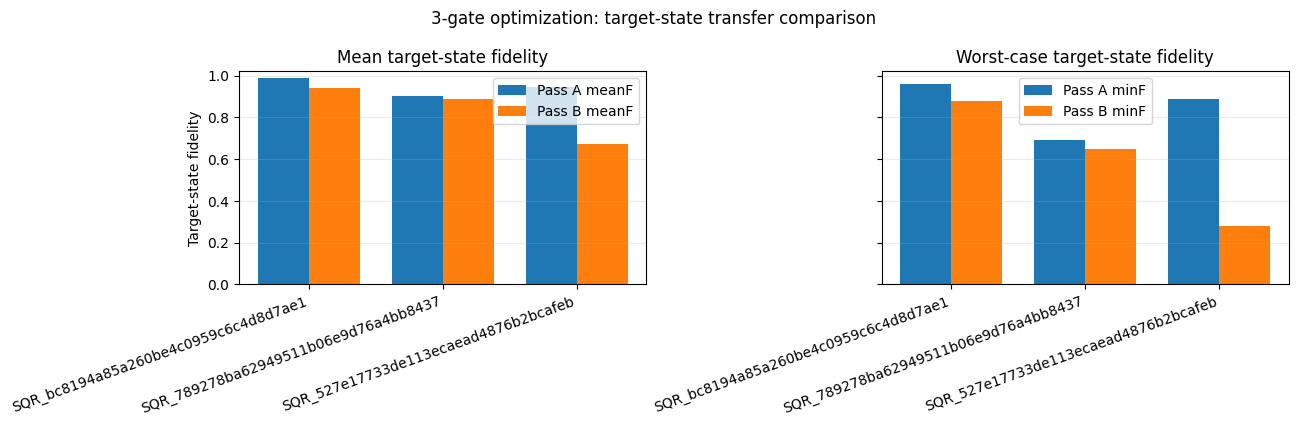


=== Pass comparison table (target-state metrics) ===
SQR_bc8194a85a260be4c0959c6c4d8d7ae1: meanF_A=0.985874, meanF_B=0.939584, minF_A=0.959449, minF_B=0.877174, dur_A=1399.0 ns, dur_B=1468.1 ns
SQR_789278ba62949511b06e9d76a4bb8437: meanF_A=0.902814, meanF_B=0.889126, minF_A=0.689781, minF_B=0.648108, dur_A=1065.7 ns, dur_B=1134.8 ns
SQR_527e17733de113ecaead4876b2bcafeb: meanF_A=0.947342, meanF_B=0.674247, minF_A=0.889444, minF_B=0.277142, dur_A=1399.0 ns, dur_B=1468.1 ns

=== Pass B per-state fidelities ===

SQR_bc8194a85a260be4c0959c6c4d8d7ae1:
  (|0>+i|1>)/sqrt2 ⊗ |+x>                0.877174
  (|0>+|1>)/sqrt2 ⊗ |g>                  0.950137
  (|0>+|2>)/sqrt2 ⊗ |e>                  0.914610
  (|0>-i|2>)/sqrt2 ⊗ |+y>                0.877174
  |0,+x>                                 0.938884
  |0,+y>                                 0.996019
  |0,e>                                  0.936619
  |0,g>                                  0.936619
  |1,+x>                                 0.9042

In [12]:
# Run two passes with notebook-friendly search defaults. Increase these for a tighter offline optimization.
# Run two passes: reference bound then requested bound (state-transfer objective)
results_pass_a = optimize_three_sqr_gates(
    min_duration_s=550e-9,
    max_duration_s=1900e-9,
    pass_name='Pass A (550ns-1900ns)',
    da_maxiter=12,
    n_restarts=4,
)

results_pass_b = optimize_three_sqr_gates(
    min_duration_s=600e-9,
    max_duration_s=2000e-9,
    pass_name='Pass B (600ns-2000ns)',
    da_maxiter=12,
    n_restarts=4,
)

# Side-by-side comparison by gate
gate_order = [r['gate'] for r in results_pass_b]
a_map = {r['gate']: r for r in results_pass_a}
b_map = {r['gate']: r for r in results_pass_b}

mean_a = np.asarray([a_map[g]['mean_after'] for g in gate_order], dtype=float)
mean_b = np.asarray([b_map[g]['mean_after'] for g in gate_order], dtype=float)
min_a = np.asarray([a_map[g]['min_after'] for g in gate_order], dtype=float)
min_b = np.asarray([b_map[g]['min_after'] for g in gate_order], dtype=float)

x = np.arange(len(gate_order))
w = 0.38
fig, ax = plt.subplots(1, 2, figsize=(13.0, 4.3), sharey=True)

ax[0].bar(x - w/2, mean_a, width=w, label='Pass A meanF')
ax[0].bar(x + w/2, mean_b, width=w, label='Pass B meanF')
ax[0].set_xticks(x)
ax[0].set_xticklabels(gate_order, rotation=20, ha='right')
ax[0].set_ylim(0.0, 1.02)
ax[0].set_ylabel('Target-state fidelity')
ax[0].set_title('Mean target-state fidelity')
ax[0].grid(alpha=0.25, axis='y')
ax[0].legend()

ax[1].bar(x - w/2, min_a, width=w, label='Pass A minF')
ax[1].bar(x + w/2, min_b, width=w, label='Pass B minF')
ax[1].set_xticks(x)
ax[1].set_xticklabels(gate_order, rotation=20, ha='right')
ax[1].set_ylim(0.0, 1.02)
ax[1].set_title('Worst-case target-state fidelity')
ax[1].grid(alpha=0.25, axis='y')
ax[1].legend()

fig.suptitle('3-gate optimization: target-state transfer comparison')
fig.tight_layout()
plt.show()

print('\n=== Pass comparison table (target-state metrics) ===')
for g in gate_order:
    print(
        f"{g}: meanF_A={a_map[g]['mean_after']:.6f}, meanF_B={b_map[g]['mean_after']:.6f}, "
        f"minF_A={a_map[g]['min_after']:.6f}, minF_B={b_map[g]['min_after']:.6f}, "
        f"dur_A={a_map[g]['duration_s']*1e9:.1f} ns, dur_B={b_map[g]['duration_s']*1e9:.1f} ns"
    )

# Show detailed per-state fidelity for Pass B (to verify landing at targets across initial states)
print('\n=== Pass B per-state fidelities ===')
for r in results_pass_b:
    print(f"\n{r['gate']}:")
    for name, fid in sorted(r['per_state_after'].items()):
        print(f"  {name:<38s} {fid:.6f}")